In [1]:
# importing the modules 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
#INPUTS - enter prediction file, AA sequences here
#rbcL
df_US_L = pd.read_csv('/Users/juliemcdonald/Documents/Shoulders_lab/Rubisco_data/heatmap_testing/input_files/enrichment.csv')

rbcL_seq='MSPQTETKASVGFKAGVKEYKLTYYTPEYQTKDTDILAAFRVTPQPGVPPEEAGAAVAAESSTGTWTTVWTDGLTSLDRYKGRCYRIERVVGEKDQYIAYVAYPLDLFEEGSVTNMFTSIVGNVFGFKALRALRLEDLRIPPAYVKTFQGPPHGIQVERDKLNKYGRPLLGCTIKPKLGLSAKNYGRAVYECLRGGLDFTKDDENVNSQPFMRWRDRFLFCAEALYKAQAETGEIKGHYLNATAGTCEEMIKRAVFARELGVPIVMHDYLTGGFTANTSLAHYCRDNGLLLHIHRAMHAVIDRQKNHGIHFRVLAKALRMSGGDHIHSGTVVGKLEGERDITLGFVDLLRDDFVEQDRSRGIYFTQDWASLPGVLPVASGGIHVWHMPALTEIFGDDSVLQFGGGTLGHPWGNAPGAVANRVALEACVKARNEGRDLAQEGNEIIREACKWSPELAAACEVWKEIVFNFAAVDVLDK*'

In [3]:
AAs = [
    "P",
    "W",
    "F",
    "Y",
    "I",
    "L",
    "M",
    "V",
    "A",
    "G",
    "S",
    "T",
    "C",
    "N",
    "Q",
    "D",
    "E",
    "K",
    "R",
    "H",
]

In [4]:
#function for numbering - no changing
def AA_numbering(string):
    amino_acid_sequence = string

    numbered_list = [f'{aa}{i}' for i, aa in enumerate(amino_acid_sequence, start=1)]

    return(numbered_list)

In [5]:
# remove FALSE values and divide into LSU and SSU - no need to change code 

# Delete the rows where score is False
mask = df_US_L['Unnamed: 3'] == "FALSE"
df_US_L = df_US_L[~mask]

# Separate into large and small subunits
RbcL_US_df = df_US_L[df_US_L['selection'] == 'NtRbcL']

print (RbcL_US_df)

    selection Unnamed: 1    Unnamed: 2 Unnamed: 3
1      NtRbcL       E19D    0.52179165       TRUE
2      NtRbcL       E19L   -2.15836252       TRUE
3      NtRbcL       E19M   0.372385904       TRUE
4      NtRbcL       E19Q  -2.049218044       TRUE
5      NtRbcL       E19R   0.469697237       TRUE
..        ...        ...           ...        ...
162    NtRbcL      V472Q  -0.075577122       TRUE
163    NtRbcL      V472S  -0.602059991       TRUE
164    NtRbcL      V472W  -0.200248089       TRUE
165    NtRbcL      D473E  -0.602059991       TRUE
166    NtRbcL      V474M  -0.602059991       TRUE

[166 rows x 4 columns]


In [6]:
#heatmap generation - no need to change code

def get_log_likelihood(mutation,df):
    result = df.loc[df["Unnamed: 1"] == mutation, "Unnamed: 2"]
    return result.values[0] if not result.empty else None

def LSU_heatmap(df,output_name):

    #unsupervised
    start_df = df['Unnamed: 1']
    start_df = start_df.str.slice(start=0,stop=1)
    end_df = df['Unnamed: 1']
    end_df = end_df.str.slice(start=-1)
    score = df['Unnamed: 2']

    #print(score)

    columns=AA_numbering(rbcL_seq)
    rows=AAs

    # Create a DataFrame filled with NaN values
    plot_df = pd.DataFrame(np.nan, index=rows, columns=columns)

    #Value = 1 for each predicted mutation
    for string in df['Unnamed: 1']:
        starting_AA=string[0:-1]
        columns+=[starting_AA]
        ending_AA=string[-1]
        for col in plot_df.columns:
            if starting_AA==col:
                for index, row in plot_df.iterrows():
                    if index==ending_AA:
                        plot_df.loc[index,col]=float(get_log_likelihood(string,df_US_L))

    #plot_df.fillna(0, inplace=True)

    plot_df.to_csv(output_name)
    
    return (plot_df)

L1=LSU_heatmap(RbcL_US_df,'enrich_out.csv')

print(L1)

   M1  S2  P3  Q4  T5  E6  T7  K8  A9  S10  ...  F469      A470      A471  \
P NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN  1.397940       NaN   
W NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
F NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
Y NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
I NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
L NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
M NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
V NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN -0.425969       NaN   
A NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
G NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   
S NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN -0.903090 -0.602060   
T NaN NaN NaN NaN NaN NaN NaN NaN NaN  NaN  ...   NaN       NaN       NaN   

(313.0, 477.0)

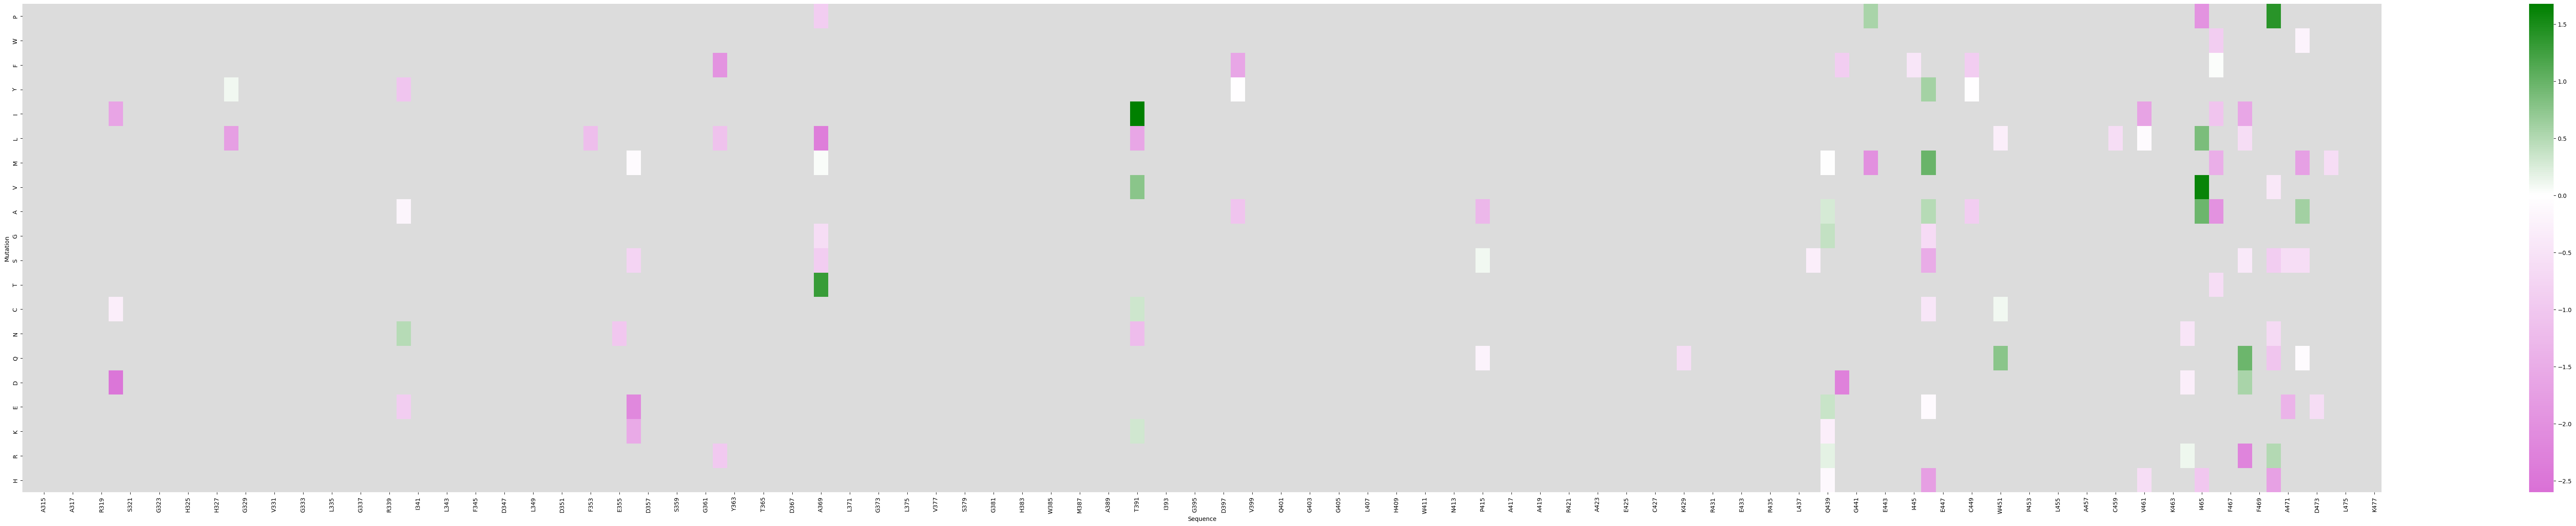

In [8]:
#sns.set(font_scale=3)

from matplotlib.colors import ListedColormap
from matplotlib.colors import LinearSegmentedColormap

# Normalize colors
colors = [(0, "orchid"), (.61, "white"), (1, "green")]
custom_cmap = LinearSegmentedColormap.from_list("custom_cmap", colors, N=256)

fig, ax = plt.subplots(figsize=(90,15))
ax = sns.heatmap(L1, cmap = custom_cmap) #linewidths=0.5, linecolor='black' )
#cmap = custom_cmap

#color values with no selection data as background
ax.set_facecolor('gainsboro')
ax.grid(False)
ax.collections[0].cmap.set_bad('gainsboro')

ax.set(xlabel="Sequence", ylabel="Mutation")

#set AA x-axis range

ax.set_xlim(313, 477)

#uncomment to save fig
#plt.savefig('enrichment_313_477.png', dpi=300)

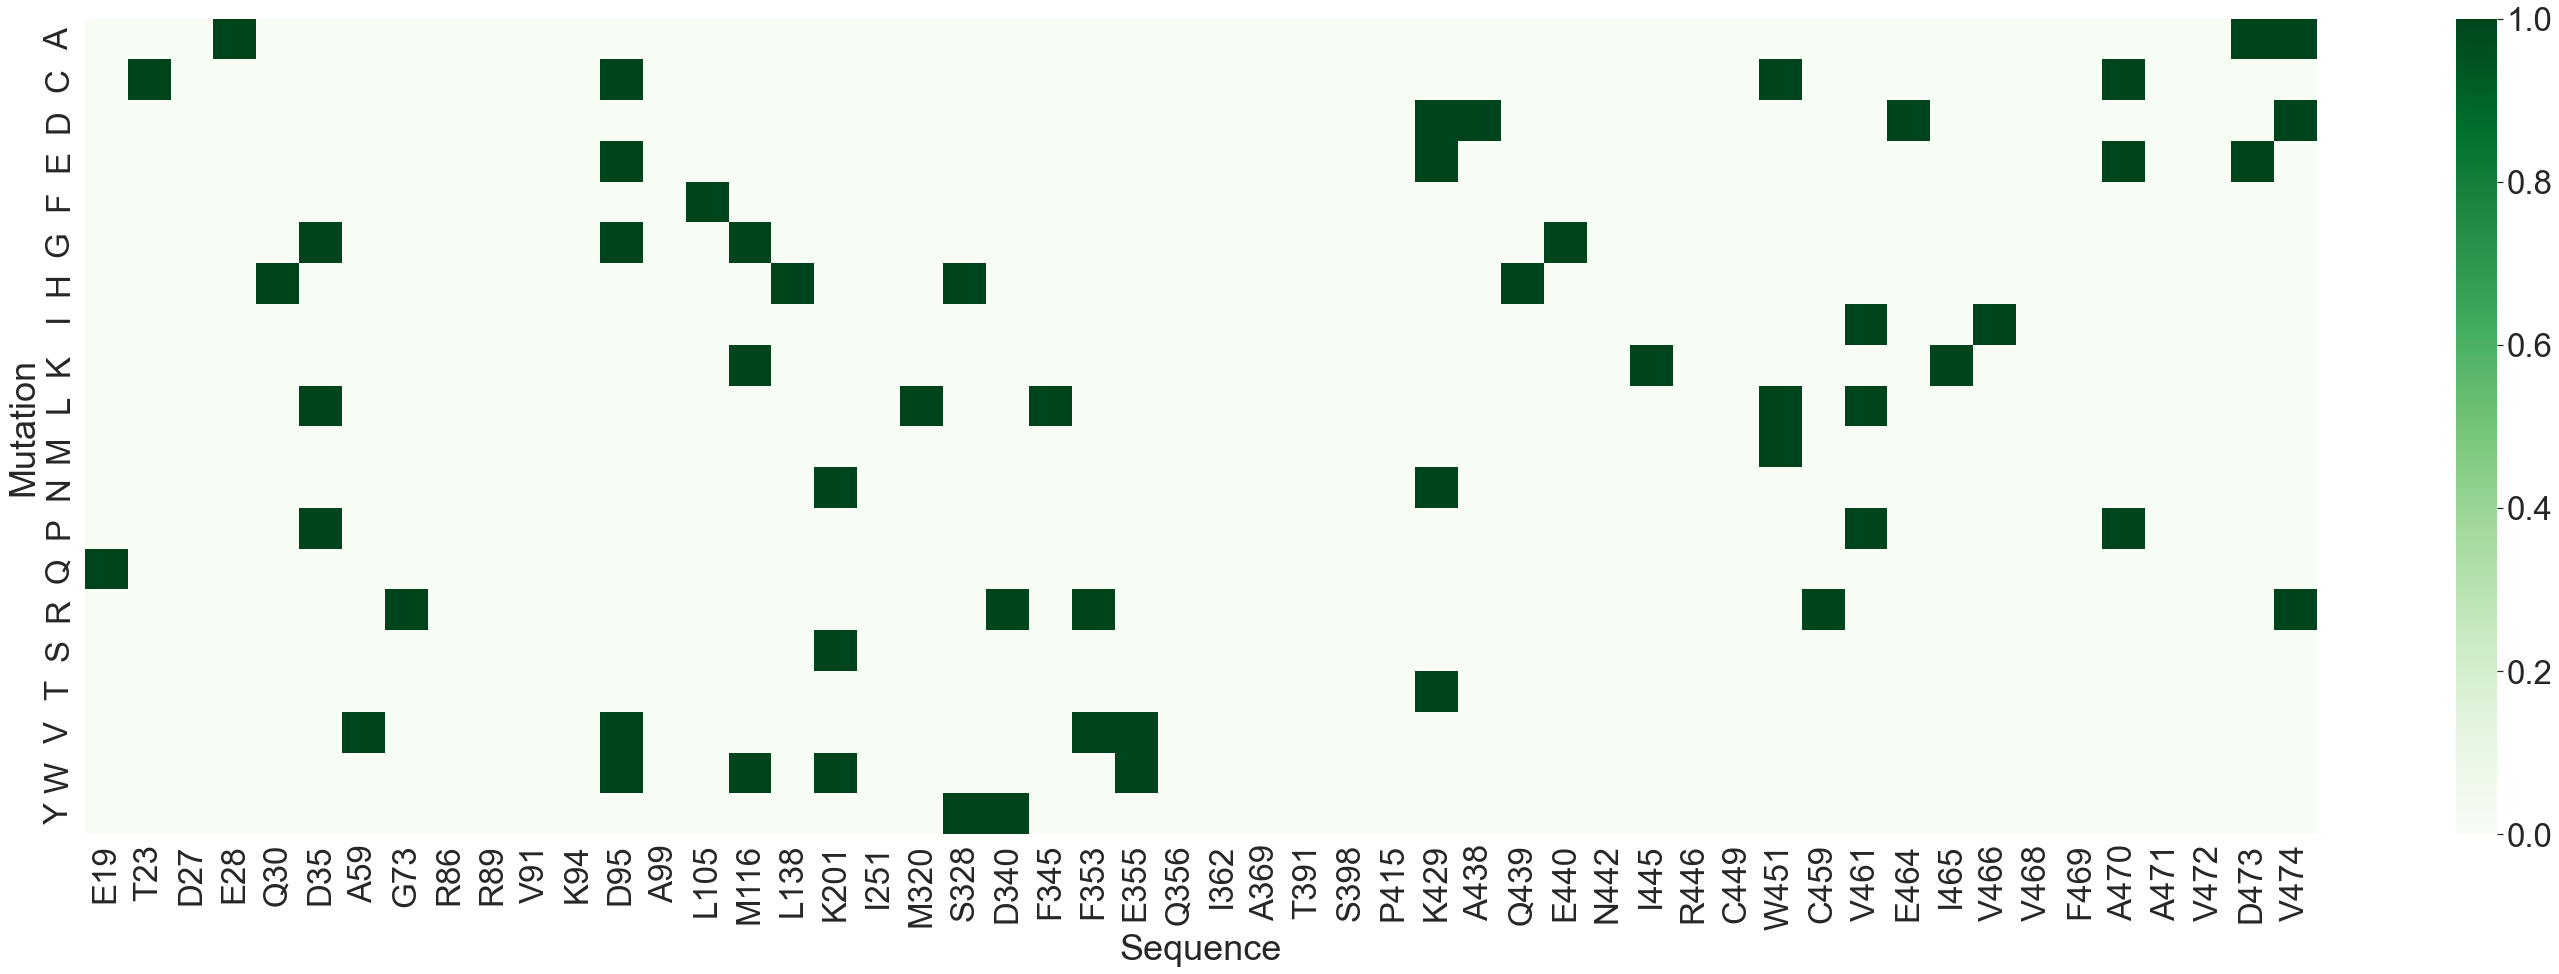